$\LARGE{Least\ Squares\ Line\ fitting}$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

In [5]:
#Least squares first attempt
def LS_fitting(X, y):
    #The line model y = mx + b
    #Need to find m and b

    #Matrix X
    mat_X = np.column_stack([X, np.ones(len(X))])
    mat_Y = y

    #The matrix m and b 
    # The matrix B = (X^T * X)^-1 * X^T * Y
    B = np.linalg.inv(mat_X.T @ mat_X) @ mat_X.T @ mat_Y

    return B

In [10]:
#Testing on a dataset

#Parameters
true_w1 = 3.5
true_w2 = -2.0
true_b = 10.0

#Generate random X data 
num_samples = 100
#Creates a 100x2 matrix of random numbers between 0 and 10
X = np.random.rand(num_samples, 2) * 10 

#Calculate the pure y values
#x[:, 0] is for the first column i.e x1 similarly X[:, 1] is for second column i.e x2
y_pure = (true_w1 * X[:, 0]) + (true_w2 * X[:, 1]) + true_b

#Adding random noise
noise = np.random.normal(loc=0.0, scale=2.0, size=num_samples)
y_noisy = y_pure + noise

#Running the function
predicted_B = LS_fitting(X, y_noisy)

print(f"Predicted Parameters: {np.round(predicted_B, 2)}")

Predicted Parameters: [ 3.58 -2.19 10.72]


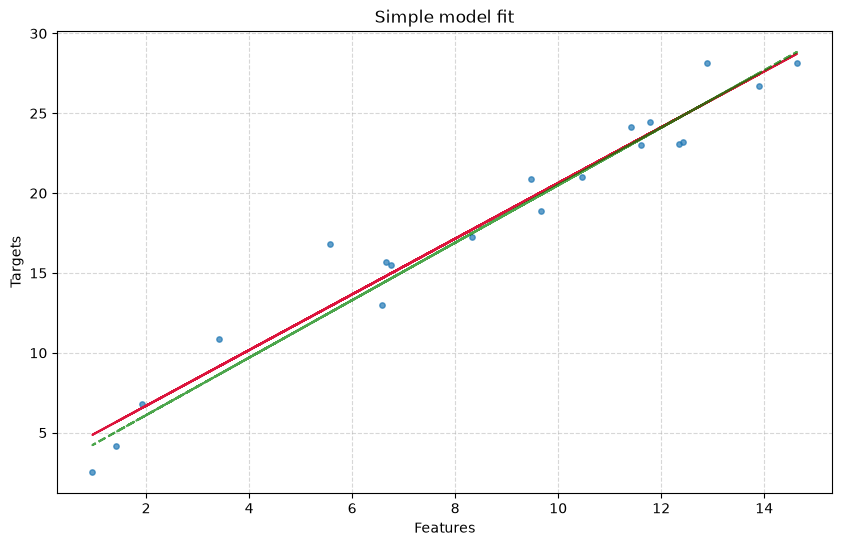

In [32]:
#Plotting a 1D X, y dataset
rng = np.random.default_rng(42)
X = rng.uniform(0, 15, size=(20, 1))
y = 2.5 + 1.8 * X[:, 0] + rng.normal(0, 2, size=20)

#Prediction
predicted_B = LS_fitting(X, y)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, label = 'Data points', alpha = 0.7, s = 15)
plt.plot(X, X*predicted_B[0] + predicted_B[1], color='crimson', label='Predicted line')
plt.plot(X, X * 1.8 + 2.5, color='green', linestyle='--', alpha=0.7)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Features')
plt.ylabel('Targets')
plt.title('Simple model fit')
plt.show()


